# Task 1: Dataset Selection and Schema Report
Dataset Name: Heart Disease Dataset
Source: Kaggle
Source URL: https://www.kaggle.com/datasets/oktayrdeki/heart-disease
License: this dataset is on Kaggle is used for healthcare professionals, researchers, and data analysts to examine trends related to heart disease, identify risk factors, and perform various health-related analyses.

Why I chose this dataset?
I chose this dataset because it contains both numerical and categorical health-related variables and has enough records for data wrangling and exploratory analysis. It also tags for data cleaning, data visualization and data analystics.

In [1]:
#Load the dataset and print its shape, column names, and dtypes
import pandas as pd

df = pd.read_csv("../data/raw/heart_disease.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (10000, 21)

Columns:
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']

Data types:
Age                     float64
Gender                      str
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits             str
Smoking                     str
Family Heart Disease        str
Diabetes                    str
BMI                     float64
High Blood Pressure         str
Low HDL Cholesterol         str
High LDL Cholesterol        str
Alcohol Consumption         str
Stress Level                str
Sleep Hours             float64
Sugar Consumption           str
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP

In [2]:
#display null counts per column.
print("Null counts:")
print(df.isna().sum())

Null counts:
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64


 Missing Values

The dataset contains missing values in several columns. Most columns have between 19 and 30 missing values. However, `Alcohol Consumption` has 2,586 missing values, which is much higher than the other columns. The `Heart Disease Status` column has no missing values. I will investigate these missing values further before deciding how to handle them during the data cleaning step.

In [3]:
#display unique-value counts per column 
print("\nUnique-value counts:")
print(df.nunique())


Unique-value counts:
Age                       63
Gender                     2
Blood Pressure            61
Cholesterol Level        151
Exercise Habits            3
Smoking                    2
Family Heart Disease       2
Diabetes                   2
BMI                     9978
High Blood Pressure        2
Low HDL Cholesterol        2
High LDL Cholesterol       2
Alcohol Consumption        3
Stress Level               3
Sleep Hours             9975
Sugar Consumption          3
Triglyceride Level       301
Fasting Blood Sugar       81
CRP Level               9974
Homocysteine Level      9980
Heart Disease Status       2
dtype: int64


Unique Values

The unique-value counts show that some columns are categorical while others contain continuous numerical measurements. For example, Gender, Smoking, Diabetes, and Heart Disease Status have only two unique values. Exercise Habits, Stress Level, and Alcohol Consumption have three unique values. In contrast, variables such as BMI, Sleep Hours, CRP Level, and Homocysteine Level have many unique values because they contain numerical measurements.

# Task 2: Data Cleaning

# 2.1. Handle missing values
start on the Alcohol Consumption has much higher missing values to investigate what cause it.


In [4]:
# Check the age of people whose Alcohol Consumption is missing

missing_alcohol = df[df["Alcohol Consumption"].isna()]

print("Number of missing Alcohol Consumption:", len(missing_alcohol))
print("\nAge statistics for missing Alcohol Consumption:")
print(missing_alcohol["Age"].describe())

Number of missing Alcohol Consumption: 2586

Age statistics for missing Alcohol Consumption:
count    2575.000000
mean       49.379806
std        18.053668
min        18.000000
25%        34.000000
50%        49.000000
75%        65.000000
max        80.000000
Name: Age, dtype: float64


In [5]:
print("\nAge values for missing Alcohol Consumption:")
print(missing_alcohol["Age"].value_counts().sort_index())


Age values for missing Alcohol Consumption:
Age
18.0    38
19.0    39
20.0    37
21.0    35
22.0    39
        ..
76.0    39
77.0    34
78.0    39
79.0    47
80.0    38
Name: count, Length: 63, dtype: int64


In [6]:
#Step 2: Check specifically for children
children_missing_alcohol = missing_alcohol[
    (missing_alcohol["Age"] >= 0) & (missing_alcohol["Age"] <= 10)
]

print("Children aged 0-8 with missing Alcohol Consumption:",
      len(children_missing_alcohol))

print("\nTheir ages:")
print(children_missing_alcohol["Age"].value_counts().sort_index())

Children aged 0-8 with missing Alcohol Consumption: 0

Their ages:
Series([], Name: count, dtype: int64)


the result show the people in this datasets are 18-80 years old, so there no children aged 0-10.
therefore, i can not decide the missing alcohol consumption values as being caused by children.
so let investigate whether the missingnesshas a relationship with the target variable before making the final decision.

In [7]:
# Compare Heart Disease Status for records with missing alcohol information

missing_alcohol = df[df["Alcohol Consumption"].isna()]

print("Heart Disease Status among missing Alcohol Consumption:")
print(missing_alcohol["Heart Disease Status"].value_counts())

print("\nPercentage:")
print(
    missing_alcohol["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Heart Disease Status among missing Alcohol Consumption:
Heart Disease Status
No     2089
Yes     497
Name: count, dtype: int64

Percentage:
Heart Disease Status
No     80.78
Yes    19.22
Name: proportion, dtype: float64


In [8]:
#compare it with the whole dataset
print("Heart Disease Status in the full dataset:")
print(
    df["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Heart Disease Status in the full dataset:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


In [9]:
# Compare age distribution

print("Age statistics - missing Alcohol Consumption:")
print(df.loc[df["Alcohol Consumption"].isna(), "Age"].describe())

print("\nAge statistics - complete Alcohol Consumption:")
print(df.loc[df["Alcohol Consumption"].notna(), "Age"].describe())

Age statistics - missing Alcohol Consumption:
count    2575.000000
mean       49.379806
std        18.053668
min        18.000000
25%        34.000000
50%        49.000000
75%        65.000000
max        80.000000
Name: Age, dtype: float64

Age statistics - complete Alcohol Consumption:
count    7396.000000
mean       49.267171
std        18.243689
min        18.000000
25%        34.000000
50%        49.000000
75%        65.000000
max        80.000000
Name: Age, dtype: float64


In [10]:
full_status = (
    df["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Heart Disease Status in the full dataset:")
print(full_status)

Heart Disease Status in the full dataset:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


`Alcohol Consumption` has about 26% missing values, but the missing group has a similar age and heart-disease distribution to the full dataset. Therefore, I will keep the column and fill its missing categorical values using the mode instead of deleting the rows.

In [11]:
# Missing values + data types
missing_info = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Data Type": df.dtypes
})

# Keep only columns with missing values
missing_info = missing_info[missing_info["Missing Values"] > 0]

print(missing_info)

                      Missing Values  Missing % Data Type
Age                               29       0.29   float64
Gender                            19       0.19       str
Blood Pressure                    19       0.19   float64
Cholesterol Level                 30       0.30   float64
Exercise Habits                   25       0.25       str
Smoking                           25       0.25       str
Family Heart Disease              21       0.21       str
Diabetes                          30       0.30       str
BMI                               22       0.22   float64
High Blood Pressure               26       0.26       str
Low HDL Cholesterol               25       0.25       str
High LDL Cholesterol              26       0.26       str
Alcohol Consumption             2586      25.86       str
Stress Level                      22       0.22       str
Sleep Hours                       25       0.25   float64
Sugar Consumption                 30       0.30       str
Triglyceride L

In [12]:
# Make a copy before cleaning
df_clean = df.copy()

# Numerical columns
numerical_columns = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"
]

# Categorical columns
categorical_columns = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Alcohol Consumption",
    "Stress Level",
    "Sugar Consumption"
]

# Fill numerical missing values with the median
for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Fill categorical missing values with the mode
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df_clean.isnull().sum())


Missing values after cleaning:
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64


In [13]:
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


I handled  missing values according to the type of variable. Numerical variables were imputed using the median because the median is less affected by extreme values. Categorical variables were imputed using the mode, which represents the most frequent category. For Alcohol Consumption, although 25.86% of values were missing, the missing group had a heart-disease distribution similar to the full dataset. Therefore, the rows were retained and the missing categorical values were replaced using the mode rather than deleting a large portion of the dataset

# 2.2. Fix dtype issues

In [14]:
# Check data types after cleaning
print("Data types after cleaning:")
print(df_clean.dtypes)

Data types after cleaning:
Age                     float64
Gender                      str
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits             str
Smoking                     str
Family Heart Disease        str
Diabetes                    str
BMI                     float64
High Blood Pressure         str
Low HDL Cholesterol         str
High LDL Cholesterol        str
Alcohol Consumption         str
Stress Level                str
Sleep Hours             float64
Sugar Consumption           str
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status        str
dtype: object


In [15]:
# Check for unexpected object/string types
print("\nColumns with object/string dtype:")
print(df_clean.select_dtypes(include=["object", "string"]).columns.tolist())


Columns with object/string dtype:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']


# 2.3. Check for duplicates and handle them

In [16]:
# Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
# Final Task 2 validation
print("Final shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())
print("Total duplicate rows:", df_clean.duplicated().sum())
print("\nData types:")
print(df_clean.dtypes)

Final shape: (10000, 21)
Total missing values: 0
Total duplicate rows: 0

Data types:
Age                     float64
Gender                      str
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits             str
Smoking                     str
Family Heart Disease        str
Diabetes                    str
BMI                     float64
High Blood Pressure         str
Low HDL Cholesterol         str
High LDL Cholesterol        str
Alcohol Consumption         str
Stress Level                str
Sleep Hours             float64
Sugar Consumption           str
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status        str
dtype: object


# Outlier Detection

I used the IQR method to identify possible outliers in the numerical columns. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were considered potential outliers.

In [18]:
#Check numerical outliers
numerical_columns = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"
]
# Check for outliers using the IQR method

for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print(f"\n{column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")


Age
Q1: 34.00
Q3: 65.00
IQR: 31.00
Lower bound: -12.50
Upper bound: 111.50
Number of outliers: 0

Blood Pressure
Q1: 134.00
Q3: 165.00
IQR: 31.00
Lower bound: 87.50
Upper bound: 211.50
Number of outliers: 0

Cholesterol Level
Q1: 187.00
Q3: 263.00
IQR: 76.00
Lower bound: 73.00
Upper bound: 377.00
Number of outliers: 0

BMI
Q1: 23.67
Q3: 34.51
IQR: 10.84
Lower bound: 7.41
Upper bound: 50.77
Number of outliers: 0

Sleep Hours
Q1: 5.46
Q3: 8.53
IQR: 3.07
Lower bound: 0.85
Upper bound: 13.14
Number of outliers: 0

Triglyceride Level
Q1: 176.00
Q3: 326.00
IQR: 150.00
Lower bound: -49.00
Upper bound: 551.00
Number of outliers: 0

Fasting Blood Sugar
Q1: 99.00
Q3: 141.00
IQR: 42.00
Lower bound: 36.00
Upper bound: 204.00
Number of outliers: 0

CRP Level
Q1: 3.68
Q3: 11.24
IQR: 7.56
Lower bound: -7.66
Upper bound: 22.59
Number of outliers: 0

Homocysteine Level
Q1: 8.73
Q3: 16.13
IQR: 7.40
Lower bound: -2.37
Upper bound: 27.23
Number of outliers: 0


#  check inconsistent for categorical values

In [19]:
# Display unique values for categorical columns
for column in categorical_columns:
    print(f"\n{column}:")
    print(df_clean[column].unique())


Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Exercise Habits:
<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

Smoking:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Family Heart Disease:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Diabetes:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

High Blood Pressure:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Low HDL Cholesterol:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

High LDL Cholesterol:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Alcohol Consumption:
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Stress Level:
<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

Sugar Consumption:
<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str


# TASK 3: Feature Engineering with GroupBy and Merge

1. GroupBy aggregation and merge

In [20]:
# Shape before transformation
print("Shape before GroupBy/Merge:", df_clean.shape)

# Group patients by Gender and calculate two statistics
gender_stats = (
    df_clean
    .groupby("Gender")
    .agg(
        Mean_Age=("Age", "mean"),
        Mean_Cholesterol=("Cholesterol Level", "mean")
    )
    .reset_index()
)

print("\nGender-level statistics:")
print(gender_stats)

# Merge the group statistics back onto the main dataframe
df_clean = df_clean.merge(
    gender_stats,
    on="Gender",
    how="left"
)

# Shape after transformation
print("\nShape after GroupBy/Merge:", df_clean.shape)

print("\nFirst 5 rows after merging:")
print(
    df_clean[
        [
            "Gender",
            "Age",
            "Cholesterol Level",
            "Mean_Age",
            "Mean_Cholesterol"
        ]
    ].head()
)

Shape before GroupBy/Merge: (10000, 21)

Gender-level statistics:
   Gender   Mean_Age  Mean_Cholesterol
0  Female  49.452792        225.977300
1    Male  49.139387        224.882119

Shape after GroupBy/Merge: (10000, 23)

First 5 rows after merging:
   Gender   Age  Cholesterol Level   Mean_Age  Mean_Cholesterol
0    Male  56.0              155.0  49.139387        224.882119
1  Female  69.0              286.0  49.452792        225.977300
2    Male  46.0              216.0  49.139387        224.882119
3  Female  32.0              293.0  49.452792        225.977300
4    Male  60.0              242.0  49.139387        224.882119


2. Pivot transformation

In [21]:

# Shape before pivot transformation
print("Shape before Pivot:", df_clean.shape)

# Create a pivot table showing average BMI
# by Exercise Habits and Heart Disease Status
exercise_bmi_pivot = pd.pivot_table(
    df_clean,
    index="Exercise Habits",
    columns="Heart Disease Status",
    values="BMI",
    aggfunc="mean"
)

print("\nAverage BMI by Exercise Habits and Heart Disease Status:")
print(exercise_bmi_pivot)

# Shape of the pivoted result
print("\nShape after Pivot:", exercise_bmi_pivot.shape)

Shape before Pivot: (10000, 23)

Average BMI by Exercise Habits and Heart Disease Status:
Heart Disease Status         No        Yes
Exercise Habits                           
High                  29.140582  29.253125
Low                   29.051082  29.232460
Medium                28.851319  29.485238

Shape after Pivot: (3, 2)


In [22]:
# Convert the pivot table into a regular dataframe
exercise_bmi_summary = exercise_bmi_pivot.reset_index()

print("\nPivot summary as dataframe:")
print(exercise_bmi_summary)


Pivot summary as dataframe:
Heart Disease Status Exercise Habits         No        Yes
0                               High  29.140582  29.253125
1                                Low  29.051082  29.232460
2                             Medium  28.851319  29.485238


In [23]:
# FINAL dataframe

print("\nFinal dataframe shape:", df_clean.shape)

print("\nNew engineered columns:")
print(df_clean[[
    "Mean_Age",
    "Mean_Cholesterol"
]].head())

print("\nFinal columns:")
print(df_clean.columns.tolist())


Final dataframe shape: (10000, 23)

New engineered columns:
    Mean_Age  Mean_Cholesterol
0  49.139387        224.882119
1  49.452792        225.977300
2  49.139387        224.882119
3  49.452792        225.977300
4  49.139387        224.882119

Final columns:
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status', 'Mean_Age', 'Mean_Cholesterol']


# TASK 4: NUMPY-BASED COMPUTATION

In [24]:
import numpy as np

# Convert Cholesterol Level to a NumPy array
cholesterol_array = df_clean["Cholesterol Level"].to_numpy()

# Calculate mean and standard deviation
cholesterol_mean = np.mean(cholesterol_array)
cholesterol_std = np.std(cholesterol_array)

# Vectorized standardization using NumPy broadcasting
cholesterol_z = (cholesterol_array - cholesterol_mean) / cholesterol_std

# Print statistics of the standardized result
print("Statistics of standardized Cholesterol Level:")
print("Mean:", np.mean(cholesterol_z))
print("Standard deviation:", np.std(cholesterol_z))
print("Minimum:", np.min(cholesterol_z))
print("Maximum:", np.max(cholesterol_z))

# Add the result back to the dataframe
df_clean["Cholesterol_Z"] = cholesterol_z

# Check the new column
print("\nFirst 10 standardized values:")
print(df_clean[["Cholesterol Level", "Cholesterol_Z"]].head(10))

Statistics of standardized Cholesterol Level:
Mean: -5.595524044110789e-17
Standard deviation: 0.9999999999999998
Minimum: -1.7336330903951487
Maximum: 1.7139908277256417

First 10 standardized values:
   Cholesterol Level  Cholesterol_Z
0              155.0      -1.618712
1              286.0       1.392213
2              216.0      -0.216679
3              293.0       1.553102
4              242.0       0.380910
5              257.0       0.725672
6              175.0      -1.159029
7              187.0      -0.883219
8              291.0       1.507133
9              252.0       0.610751


# Task 5: Exploratory Visualization

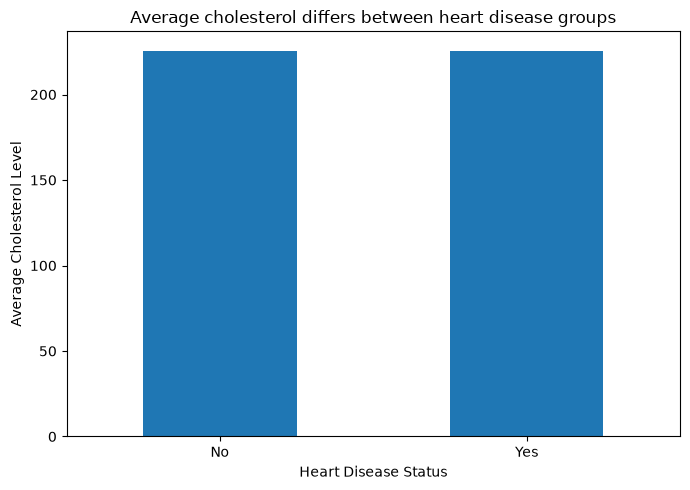

In [25]:
#Chart 1  Cholesterol and Heart Disease

import matplotlib.pyplot as plt

# Calculate average cholesterol by heart disease status
cholesterol_by_disease = (
    df_clean
    .groupby("Heart Disease Status")["Cholesterol Level"]
    .mean()
)

plt.figure(figsize=(7, 5))

cholesterol_by_disease.plot(kind="bar")

plt.xlabel("Heart Disease Status")
plt.ylabel("Average Cholesterol Level")
plt.title("Average cholesterol differs between heart disease groups")
plt.xticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/a2_chart1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

<Figure size 800x500 with 0 Axes>

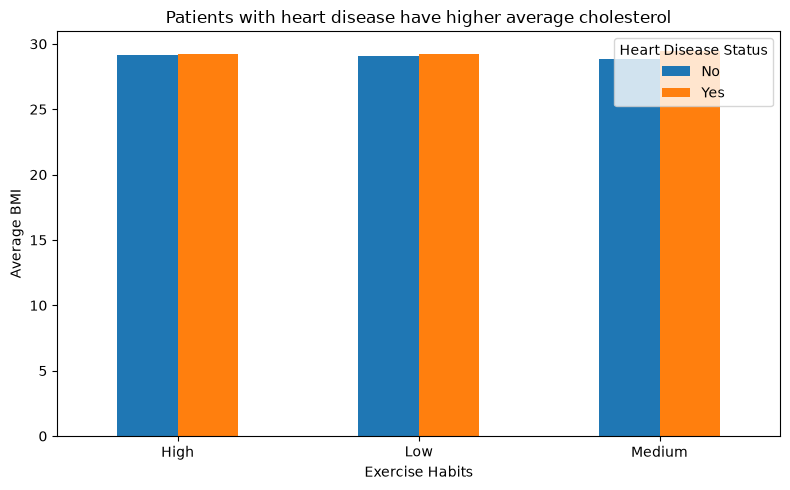

In [26]:
#Chart 2: Exercise, BMI and Heart Disease
plt.figure(figsize=(8, 5))

exercise_bmi_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Exercise Habits")
plt.ylabel("Average BMI")
plt.title("Patients with heart disease have higher average cholesterol")
plt.xticks(rotation=0)
plt.legend(title="Heart Disease Status")

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/a2_chart2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [27]:
print(cholesterol_by_disease)
print(exercise_bmi_pivot)

Heart Disease Status
No     225.3685
Yes    225.6625
Name: Cholesterol Level, dtype: float64
Heart Disease Status         No        Yes
Exercise Habits                           
High                  29.140582  29.253125
Low                   29.051082  29.232460
Medium                28.851319  29.485238


# Task 6: Cleaned Dataset and Report

6.1 Save the cleaned, feature-engineered dataset

In [28]:
import os

# Create the processed-data folder if it does not exist
os.makedirs("../data/processed", exist_ok=True)

# Save the cleaned and feature-engineered dataset
df_clean.to_csv(
    "../data/processed/heart_disease_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print("Final shape:", df_clean.shape)

Cleaned dataset saved successfully.
Final shape: (10000, 24)


6.2 Verify the saved dataset

In [29]:
# Verify the final dataset
print("Final dataset shape:", df_clean.shape)

print("\nTotal missing values:")
print(df_clean.isnull().sum().sum())

print("\nTotal duplicate rows:")
print(df_clean.duplicated().sum())

print("\nFinal columns:")
print(df_clean.columns.tolist())

Final dataset shape: (10000, 24)

Total missing values:
0

Total duplicate rows:
0

Final columns:
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status', 'Mean_Age', 'Mean_Cholesterol', 'Cholesterol_Z']
